# Inverse designed grating coupler

Updating... check back later.

## Config

In [ ]:
import os
import numpy as np
import gdsfactory as gf
from gdsfactory.technology import LogicalLayer, LayerLevel, LayerStack
import matplotlib.pyplot as plt
import luminescent as lm

path = os.path.join("runs", "GC")

theta = 10 * np.pi / 180
wavelength = 1.55
bandwidth = 0.005
nwls = 3
wavelengths = np.linspace(wavelength - bandwidth / 2, wavelength + bandwidth / 2, nwls)
nres = 6

material_core = "Si"
material_clad = "SiO2"
materials = {
    "Si": lm.Material(3.45),
    "SiO2": lm.Material(1.44),
}

n_core = materials[material_core]["n"]
n_clad = materials[material_clad]["n"]
lambda_core = wavelength / n_core
lambda_clad = wavelength / n_clad
dx = lambda_core / nres

background = material_clad
materials["design"] = lm.PlaceholderMaterial(n_core)

r = 3
R = 1.5 * r
w_design = 2 * R
hang = 4 * lambda_core
l_design = w_design + 2 * r + hang
w_wg = 0.5
l_wg = 8 * w_wg
taper = 0

h_wg = 0.22
h_base = 0.15
h_rib = 0.07

boundaries = ["PML", ["PEC", "PML"], "PML"]
PML_decay = [0.001, 0.1, 0.01]
relative_courant = 0.95
frame_every = 2
lmin = 0.1

lateral_port_margin = w_wg
height_port_margin = 1.5 * h_wg
margin = 1.5 * lateral_port_margin
zmargin = 1.5 * height_port_margin

port_offset = np.cos(theta) * lambda_clad / 2
source_offset = np.cos(theta) * lambda_clad / 4
z_port = h_wg + port_offset
ox_port = np.sin(theta) * (source_offset + port_offset)

zmin = -zmargin
zmax = h_wg + port_offset + source_offset

WG = (1, 0)
SLAB = (2, 0)
RIB = (3, 0)
CLAD = (4, 0)
DESIGN = (1001, 0)

In [ ]:
# layer stack. lower mesh order layers override higher mesh order layers.
# for 2.5D problems, the mesher slices through the middle of the core layer.
zmin_design = 0
h_design = h_base

layers = {
    "core": LayerLevel(
        layer=LogicalLayer(layer=WG),
        zmin=0,
        thickness=h_wg,
        material=material_core,
        mesh_order=200,
    ),
    "base": LayerLevel(
        layer=LogicalLayer(layer=SLAB),
        zmin=0,
        thickness=h_base,
        material=material_core,
        mesh_order=100,
    ),
    "design": LayerLevel(
        layer=LogicalLayer(layer=DESIGN),
        zmin=zmin_design,
        thickness=h_design,
        material="design",
        mesh_order=1,
    ),
}
layer_stack = LayerStack(layers=layers)

mirrors = ["y-"]

views = [
    lm.View("Ey", y=0, z=zmin_design + h_design / 2),
    lm.View("Ey", z=zmin_design + h_design / 2),
]

## Geometry

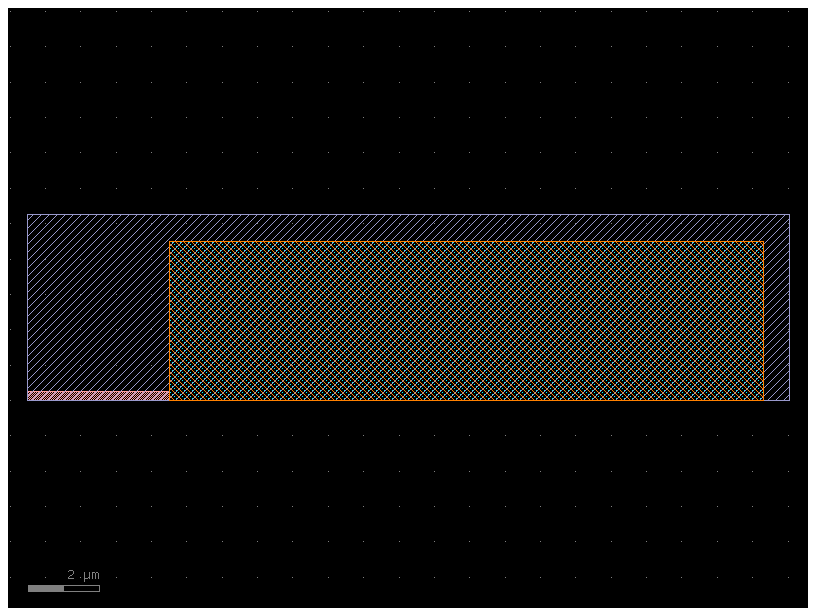

In [ ]:
# Build the gdsfactory component to be optimized.
c = gf.Component()
d = c << lm.mimo(
    l_design,
    w_design / 2,
    west=[w_wg / 4],
    w_wg=w_wg / 2,
    l_wg=l_wg,
    layer_wg=WG,
    layer_design=(DESIGN,),
    layer_fill=SLAB,
    taper=[(taper / 2, 0)],
)

ox_design = -l_design + R + hang
d.movex(ox_design)

c << gf.components.bbox(component=c, layer=CLAD, top=margin, right=margin)

c.add_port("o1", port=d.ports["o1"])

sensors = [
    lm.Sensor(
        "wg",
        start=[-w_wg / 4 - lateral_port_margin, zmin],
        stop=[w_wg / 4, zmax],
        boundaries=[("PML", "PEC"), "PML"],
        mode_solver_wavelengths=[wavelength],
        modes="auto",
        nmodes=1,
    ),
    lm.Sensor(
        "beam",
        modes=[
            lm.gaussian_mode(
                r,
                R,
                Z=1 / n_clad,
                dx=dx,
                theta=theta,
                wavelength=wavelength,
                half="y+",
            )
        ],
        start=[-R, 0],
        stop=[R, R],
        boundaries=["PML", ("PEC", "PML")],
    ),
]

origin = [ox_port, 0, z_port]
frame = [[1, 0, 0], [0, 1, 0], [0, 0, 1]]
sources = [
    lm.Source(
        "o2",
        origin,
        frame,
        wavelength=wavelength,
        bandwidth=wavelength / 5,
        sensor="beam",
    )
]
monitors = [
    lm.Monitor("o1", *lm.from_gf_port(c, "o1"), sensor="wg"),
    lm.Monitor("o2", origin, frame, sensor="free"),
]
tmax = (
    1.5
    * (
        (port_offset + source_offset) / np.cos(theta) * n_clad
        + (l_design + w_design / 2 + l_wg) * n_core
    )
    / wavelength
    + sources[0]["duration"]
)

bbox = c.bbox_np().tolist()
bbox[0].append(zmin)
bbox[1].append(zmax)

c.plot()

In [ ]:
optimizer = lm.Optimizer(
    stoploss=0.3,
    lowloss=0.6,
    iters=5,
    momentum=0.7,
)
targets = [
    lm.Target(src="o2@0-", dst="o1@0+", target=1, weight=1 / nwls, wavelength=wl)
    for wl in wavelengths
]
designs = [
    lm.Design(
        name="design",
        layer=DESIGN,
        lmin=lmin,
        fill_material=material_core,
        void_material=material_clad,
        component=c,
        layer_stack=layer_stack,
        materials=materials,
        repdims=[3],
        anchordims=[],
    )
]

## Solve

(12, 3)
(12, 3)
(12, 3)
origin: [-14.5, 0.125, 0.0], frame: [[-1.2246467991473532e-16, -1.0, 0], [0, 0, 1], [-1.0, 1.2246467991473532e-16, 0]], start: [-0.625, -0.495], stop: [0.125, np.float64(1.0150270922754805)],
polyeps: [(<POLYGON ((0.125 0, -0.125 0, -0.125 0, -0.125 5.5e-5, -0.125 0.22, -0.125 0...>, 11.902500000000002, 'core'), (<POLYGON ((0.125 -0.495, 0.125 1.015, -0.625 1.015, -0.625 -0.495, 0.125 -0....>, 2.0736, '')]
showing modes for wavelength 1.55
mode Boundary conditions: 00A0


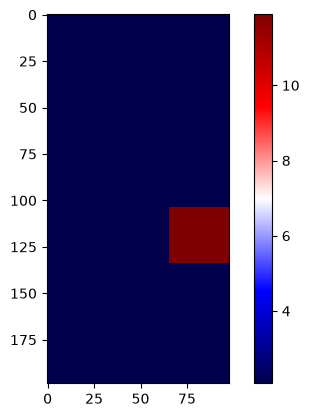

wg/1.55 mode 0 (neff=2.418+0.000j)
saving mode to /home/weihu/moon/luminescent/runs/GC/modes/wg/1.55/0.npz
using simulation folder /home/weihu/moon/luminescent/runs/GC


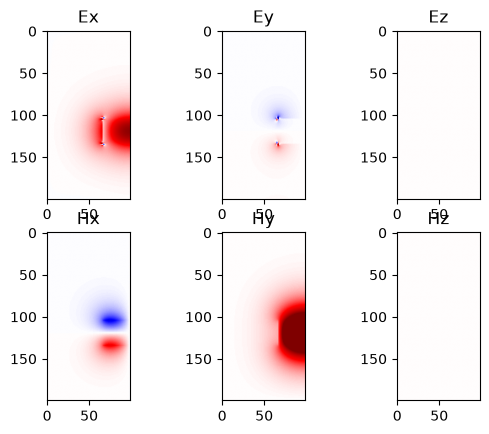

In [ ]:
kwargs = dict(
    path=path,
    wavelength=wavelength,
    wavelengths=wavelengths,
    sensors=sensors,
    monitors=monitors,
    sources=sources,
    boundaries=boundaries,
    bbox=bbox,
    materials=materials,
    background=background,
    nres=nres,
    tmax=tmax,
    PML_decay=PML_decay,
    relative_courant=relative_courant,
    frame_every=frame_every,
    views=views,
    designs=designs,
    targets=targets,
    optimizer=optimizer,
)

lm.mesh(path, c, layer_stack, materials, zmin, zmax)
lm.setup(**kwargs)

## Movie
